# M2 — Statistiques descriptives DiagOps (complété)

Notebook online Atlas : description du parc, qualité, relations et recommandations.
Les figures sont aussi exportées dans `reports/figures/`.


In [1]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler

SEED = 20260802
sns.set_theme(style='whitegrid')
if os.environ.get('DIAGOPS_DATA_DIR'):
    DATA_DIR = Path(os.environ['DIAGOPS_DATA_DIR']).resolve()
else:
    roots = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    DATA_DIR = next((root / 'data_pack' / '2026-S1' for root in roots if (root / 'data_pack' / 'MANIFEST.yaml').is_file()), None)
    if DATA_DIR is None:
        raise FileNotFoundError('Racine du dépôt S04 introuvable')
FIG_DIR = Path('reports/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR


PosixPath('/Users/segalini-briant/Documents/GitHub/atlas-cisia-s04/data_pack/2026-S1')

## 1. Chargement et compréhension


In [2]:
equipment = pd.read_csv(DATA_DIR / 'equipment' / 'equipment.csv')
events = pd.read_csv(DATA_DIR / 'events' / 'events.csv')
maintenance = pd.read_csv(DATA_DIR / 'maintenance' / 'maintenance_history.csv')
print('equipment', equipment.shape, 'events', events.shape, 'maintenance', maintenance.shape)
print('clés:', 'equipment_id / event_id / maintenance_id')

# Jointures et contrôle de cardinalité
j_ev_eq = events.merge(equipment, on='equipment_id', how='left', indicator=True)
print('events⋈equipment:', len(events), '→', len(j_ev_eq), 'orphelins', (j_ev_eq['_merge']!='both').sum())
j_mt_ev = maintenance.merge(events[['event_id']], on='event_id', how='left', indicator=True)
print('maint⋈events:', len(maintenance), '→', len(j_mt_ev), 'orphelins', (j_mt_ev['_merge']!='both').sum())
j_mt_eq = maintenance.merge(equipment[['equipment_id']], on='equipment_id', how='left', indicator=True)
print('maint⋈equipment:', len(maintenance), '→', len(j_mt_eq), 'orphelins', (j_mt_eq['_merge']!='both').sum())


equipment (420, 7) events (520, 7) maintenance (1800, 13)
clés: equipment_id / event_id / maintenance_id
events⋈equipment: 520 → 525 orphelins 1
maint⋈events: 1800 → 1814 orphelins 1
maint⋈equipment: 1800 → 1814 orphelins 1


**Interprétation §1**
- Une ligne = un équipement / un événement / une intervention.
- Relations : `events.equipment_id` → equipment ; `maintenance.event_id` → events ; `maintenance.equipment_id` → equipment.
- Jointures gauche : 520 événements, 1 orphelins équipement ; maintenance : 1 event_id absents, 1 equipment_id absents.
- La jointure n'explose pas le nombre de lignes (cardinalité 1–n respectée sur les clés attendues), mais des orphelins existent (qualité).


## 2. Description statistique


In [3]:
# Effectifs
print('Par site:\n', equipment['site_id'].value_counts())
print('Par type:\n', equipment['equipment_type'].value_counts().head())
print('Par criticité:\n', equipment['criticality'].value_counts())

dt = pd.to_numeric(maintenance['downtime_minutes'], errors='coerce')
print('downtime mode', dt.mode().iloc[0] if not dt.mode().empty else None)
print('downtime mean', dt.mean(), 'median', dt.median())
print('quartiles', dt.quantile([0.25,0.5,0.75]).to_dict())
print('déciles hauts', dt.quantile([0.8,0.9,0.95]).to_dict())
print('variance', dt.var(), 'std', dt.std(), 'IQR', (dt.quantile(0.75)-dt.quantile(0.25)))

# Âge approximatif
eq2 = equipment.copy()
eq2['commissioning_date'] = pd.to_datetime(eq2['commissioning_date'], errors='coerce')
eq2['age_years'] = (pd.Timestamp('2026-08-01') - eq2['commissioning_date']).dt.days / 365.25
print('âge médian (années)', eq2['age_years'].median())

# Comparaison 2 sites
for site in ['SITE-NORD', 'SITE-OUEST']:
    ids = set(equipment.loc[equipment.site_id==site, 'equipment_id'])
    sub = dt[maintenance.equipment_id.isin(ids)]
    print(site, 'n_interventions', sub.notna().sum(), 'median_down', sub.median())


Par site:
 site_id
SITE-NORD     176
SITE-SUD      137
SITE-EST       91
SITE-OUEST     16
Name: count, dtype: int64
Par type:
 equipment_type
pump          56
robot         45
conveyor      41
compressor    38
oven          36
Name: count, dtype: int64
Par criticité:
 criticality
medium      174
high        122
low          76
critical     48
Name: count, dtype: int64
downtime mode 0
downtime mean 211.095 median 153.0
quartiles {0.25: 96.0, 0.5: 153.0, 0.75: 204.0}
déciles hauts {0.8: 220.0, 0.9: 267.0, 0.95: 295.04999999999995}
variance 5544241.459007781 std 2354.6212984273675 IQR 108.0
âge médian (années) 11.854893908281998
SITE-NORD n_interventions 814 median_down 148.0
SITE-OUEST n_interventions 76 median_down 119.0


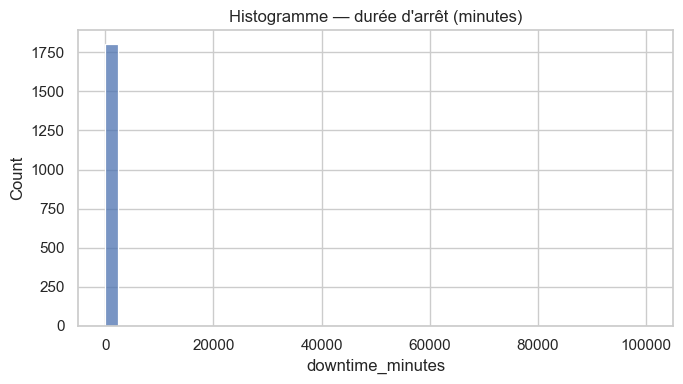

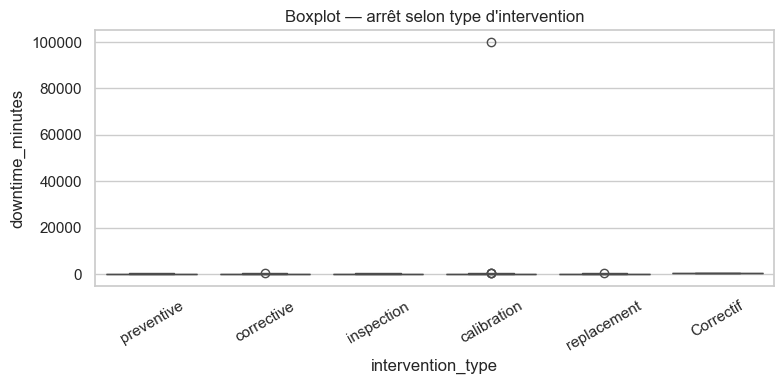

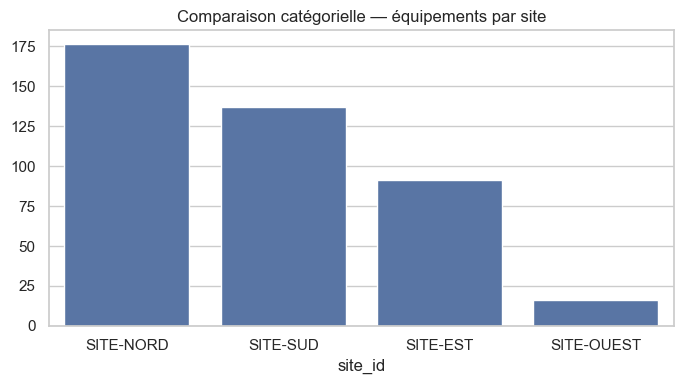

In [4]:
dt = pd.to_numeric(maintenance['downtime_minutes'], errors='coerce')
lh = pd.to_numeric(maintenance['labor_hours'], errors='coerce')

fig, ax = plt.subplots(figsize=(7,4))
sns.histplot(dt.dropna(), bins=40, ax=ax)
ax.set_title("Histogramme — durée d'arrêt (minutes)")
fig.tight_layout(); fig.savefig(FIG_DIR/'hist_downtime.png', dpi=120); plt.show()

fig, ax = plt.subplots(figsize=(8,4))
sns.boxplot(data=maintenance.assign(downtime_minutes=dt), x='intervention_type', y='downtime_minutes', ax=ax)
ax.set_title("Boxplot — arrêt selon type d'intervention")
ax.tick_params(axis='x', rotation=30)
fig.tight_layout(); fig.savefig(FIG_DIR/'box_downtime_type.png', dpi=120); plt.show()

fig, ax = plt.subplots(figsize=(7,4))
vc = equipment['site_id'].value_counts()
sns.barplot(x=vc.index.astype(str), y=vc.values, ax=ax)
ax.set_title('Comparaison catégorielle — équipements par site')
fig.tight_layout(); fig.savefig(FIG_DIR/'bar_sites.png', dpi=120); plt.show()


**Interprétation §2**
- SITE-OUEST est très peu représenté (16 équipements) → conclusions par site fragiles.
- Moyenne downtime ≈ 211.1 min vs médiane ≈ 153.0 min : distribution asymétrique (queue longue) ; la médiane décrit mieux le « habituel ».
- Les déciles hauts montrent des arrêts très longs ; le boxplot par type d'intervention aide à comparer les populations.


## 3. Qualité et relations


In [5]:
print('Manquants maintenance:\n', maintenance.isna().sum().sort_values(ascending=False).head(8))
print('Doublons equipment_id', equipment.equipment_id.duplicated().sum())
print('Doublons event_id', events.event_id.duplicated().sum())
print('Doublons maintenance_id', maintenance.maintenance_id.duplicated().sum())

dt = pd.to_numeric(maintenance['downtime_minutes'], errors='coerce')
q1, q3 = dt.quantile(0.25), dt.quantile(0.75)
iqr = q3 - q1
out_iqr = ((dt < q1 - 1.5*iqr) | (dt > q3 + 1.5*iqr)).sum()
out_z = ((dt - dt.mean()).abs() > 3*dt.std()).sum()
print('atypiques IQR', int(out_iqr), 'atypiques |z|>3', int(out_z))
print('négatifs downtime', int((dt < 0).sum()))


Manquants maintenance:
 closed_at            48
parts_cost_eur       27
labor_hours           1
maintenance_id        0
event_id              0
equipment_id          0
opened_at             0
intervention_type     0
dtype: int64
Doublons equipment_id 4
Doublons event_id 4
Doublons maintenance_id 5
atypiques IQR 5 atypiques |z|>3 1
négatifs downtime 1


                  downtime_minutes  labor_hours  parts_cost_eur
downtime_minutes          1.000000    -0.002465        0.043414
labor_hours              -0.002465     1.000000        0.491345
parts_cost_eur            0.043414     0.491345        1.000000


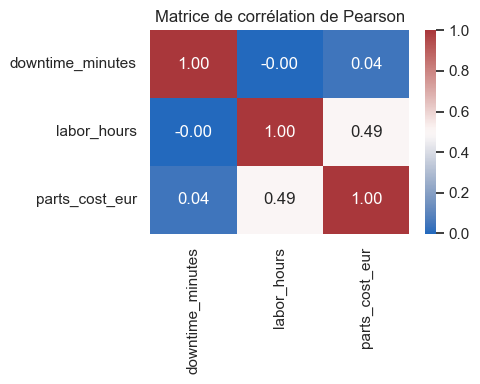

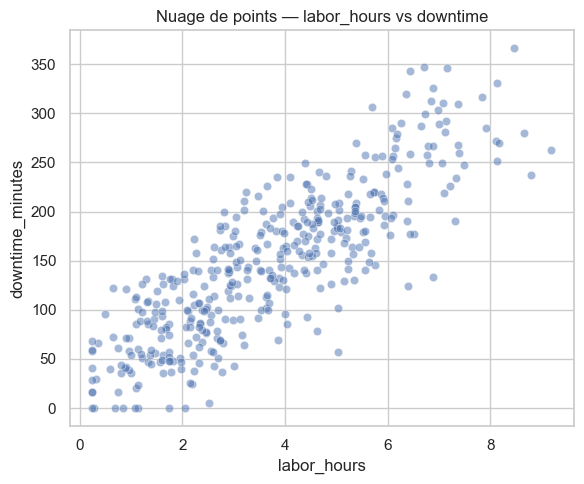

moyenne downtime avant 212.32336343115125 après clip p99 155.9466365688488


In [6]:
dt = pd.to_numeric(maintenance['downtime_minutes'], errors='coerce')
lh = pd.to_numeric(maintenance['labor_hours'], errors='coerce')
cost = pd.to_numeric(maintenance['parts_cost_eur'], errors='coerce')
num = pd.DataFrame({'downtime_minutes':dt,'labor_hours':lh,'parts_cost_eur':cost}).dropna()

corr = num.corr(method='pearson')
print(corr)
fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='vlag', ax=ax)
ax.set_title('Matrice de corrélation de Pearson')
fig.tight_layout(); fig.savefig(FIG_DIR/'corr_heatmap.png', dpi=120); plt.show()

sample = num.sample(n=min(400, len(num)), random_state=42)
fig, ax = plt.subplots(figsize=(6,5))
sns.scatterplot(data=sample, x='labor_hours', y='downtime_minutes', alpha=0.5, ax=ax)
ax.set_title('Nuage de points — labor_hours vs downtime')
fig.tight_layout(); fig.savefig(FIG_DIR/'scatter_labor_downtime.png', dpi=120); plt.show()

# Sensibilité à une valeur extrême
base = num['downtime_minutes'].mean()
clipped = num['downtime_minutes'].clip(upper=num['downtime_minutes'].quantile(0.99))
print('moyenne downtime avant', base, 'après clip p99', clipped.mean())


In [7]:
# Encodage + normalisation vs standardisation
enc = pd.get_dummies(maintenance[['intervention_type']], drop_first=True)
print('encodage one-hot intervention_type, colonnes:', list(enc.columns)[:5], '...')

two = num[['downtime_minutes','labor_hours']]
mm = MinMaxScaler().fit_transform(two)
ss = StandardScaler().fit_transform(two)
cmp = pd.DataFrame({
    'down_minmax': mm[:,0], 'labor_minmax': mm[:,1],
    'down_z': ss[:,0], 'labor_z': ss[:,1]
})
print(cmp.describe().round(3))


encodage one-hot intervention_type, colonnes: ['intervention_type_calibration', 'intervention_type_corrective', 'intervention_type_inspection', 'intervention_type_preventive', 'intervention_type_replacement'] ...
       down_minmax  labor_minmax    down_z   labor_z
count     1772.000      1772.000  1772.000  1772.000
mean         0.003         0.401     0.000     0.000
std          0.024         0.212     1.000     1.000
min          0.000         0.000    -0.108    -1.896
25%          0.001         0.242    -0.049    -0.752
50%          0.002         0.392    -0.025    -0.045
75%          0.002         0.538    -0.004     0.647
max          1.000         1.000    42.061     2.828


**Interprétation §3**
- Manquants notables : `closed_at`, parfois `parts_cost_eur` — à documenter, pas à inventer.
- Doublons d'identifiants présents (à croiser avec `output/quarantine.csv` du présentiel).
- Atypiques IQR / |z|>3 : rares ou extrêmes ; certains négatifs sont **impossibles** → quarantaine, pas suppression silencieuse.
- Corrélation Pearson : une liaison statistique n'implique **pas** une causalité sur la durée d'arrêt.
- MinMax borne [0,1] ; StandardScaler centre/réduit — utiles pour comparer des échelles différentes.


## 4. Recommandation et réponses aux questions du brief

### Classification des variables
| Statut | Variables | Justification |
|---|---|---|
| Utilisables en l'état | `equipment_id`, `event_id`, `maintenance_id`, `site_id`, `equipment_type`, `intervention_type`, `severity`/`criticality` (après contrôle domaine) | Clés et catégories structurantes, utiles au suivi |
| À nettoyer / documenter | `downtime_minutes`, `labor_hours`, `parts_cost_eur`, `closed_at`, `rated_power_kw`, notes | Manquants, extrêmes, parfois valeurs impossibles ; PII dans notes |
| À écarter provisoirement | notes brutes non masquées ; éventuelles colonnes hors contrat | Risque PII / bruit ; utiliser `processed/` du présentiel |

### Réponses synthétiques (1→16)
1. Ligne = équipement / événement / intervention.  
2. Jointures via `equipment_id` et `event_id`.  
3. Cardinalité stable ; orphelins FK détectés (ne pas les ignorer).  
4. Effectifs par site/type/criticité calculés ; SITE-OUEST faible.  
5. Âge approximatif via `commissioning_date` ; catégories rares à signaler.  
6. Moyenne ≠ médiane sur downtime → asymétrie.  
7. Quartiles/déciles : queue longue d'arrêts longs.  
8. Boxplot : variation selon `intervention_type`.  
9. Manquants : surtout `closed_at`, coûts.  
10. Négatifs / hors domaine / extrêmes.  
11. Quarantaine ou masquage justifié (présentiel) ; mesurer l'effet (ex. moyenne après clip).  
12–14. Corrélations observées ≠ causalité ; vérifier après traitement d'extrêmes.  
15. Normalisation vs standardisation : échelles différentes, même information relative.  
16. Recommandation : table ci-dessus ; pour modélisation future partir de `output/processed/` + journal des règles.
